In [ ]:
!pip install kaggle -q

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
#Unzipping
!unzip -q plantvillage-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    validation_split=0.2
)

DATA_DIR = '/content/plantvillage dataset/color'
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 16

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

num_classes = len(train_generator.class_indices)
print(f"Found {num_classes} classes.")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 38 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

base_model_effnet = EfficientNetV2B0(
    input_shape=IMAGE_SIZE + [3],
    weights='imagenet',
    include_top=False
)
base_model_effnet.trainable = False

model = Sequential([
    base_model_effnet,
    Flatten(),
    Dense(num_classes, activation='softmax') # Add a dense layer with num_classes units and softmax activation
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │     2,383,398 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,302,710 (31.67 MB)

 Trainable params: 2,383,398 (9.09 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

EPOCHS = 200
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
  train_generator,
  validation_data=validation_generator,
  epochs=EPOCHS,
  steps_per_epoch=steps_per_epoch,
  validation_steps=validation_steps,
  callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 132s 37ms/step - accuracy: 0.8254 - loss: 2.5717 - val_accuracy: 0.9418 - val_loss: 1.2697
Epoch 2/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 114s 33ms/step - accuracy: 0.9592 - loss: 0.8606 - val_accuracy: 0.9521 - val_loss: 1.5065
Epoch 3/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 142s 33ms/step - accuracy: 0.9729 - loss: 0.7058 - val_accuracy: 0.9579 - val_loss: 1.6459
Epoch 4/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 89s 33ms/step - accuracy: 0.9767 - loss: 0.6658 - val_accuracy: 0.9661 - val_loss: 1.4354
Epoch 5/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 160s 40ms/step - accuracy: 0.9839 - loss: 0.4945 - val_accuracy: 0.9647 - val_loss: 1.5584
Epoch 6/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 142s 52ms/step - accuracy: 0.9852 - loss: 0.4483 - val_accuracy: 0.9692 - val_loss: 1.6731
Epoch 7/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 156s 35ms/step - accuracy: 0.9885 - loss: 0.3350 - val_accuracy: 0.9699 - val_loss: 1.6840
Epoch 8/200
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 88s 33ms/step - accu

ValueError: x and y must have same first dimension, but have shapes (200,) and (29,)

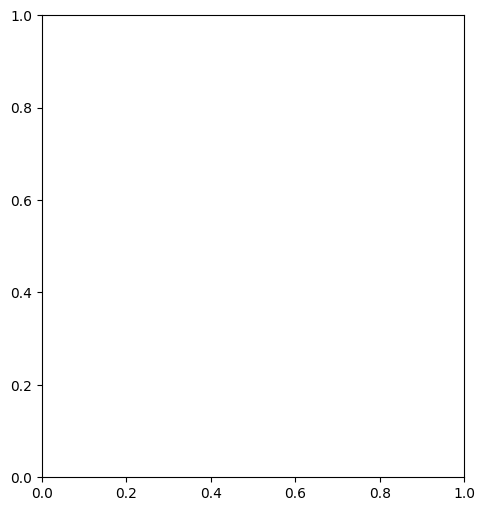

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("Making predictions on the validation set...")

y_true = validation_generator.classes
class_indices = validation_generator.class_indices
target_names_list = [list(class_indices.keys())[i] for i in range(len(class_indices))]


y_pred_probs = model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE + (validation_generator.samples % BATCH_SIZE > 0))
y_pred = np.argmax(y_pred_probs, axis=1)

validation_generator.reset()
y_true_batches = []
for i in range(validation_generator.samples // BATCH_SIZE + (validation_generator.samples % BATCH_SIZE > 0)):
    _, labels = validation_generator.__next__()
    y_true_batches.extend(np.argmax(labels, axis=1))

y_true = np.array(y_true_batches)


if len(y_pred) > len(y_true):
    y_pred = y_pred[:len(y_true)]
elif len(y_true) > len(y_pred):
     y_true = y_true[:len(y_pred)]


print("\n--- Full Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names_list, zero_division=0))


print("\n--- Summary Metrics ---")
acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"  Accuracy: {acc * 100:.2f}%")
print(f" Precision: {pre * 100:.2f}% (Weighted Avg.)")
print(f"    Recall: {rec * 100:.2f}% (Weighted Avg.)")
print(f"  F1-Score: {f1 * 100:.2f}% (Weighted Avg.)")